# Predicting the temperature of a star

Independent project of the "Neural networks" module.

The goal of the work is to build a neural network that predicts the temperature on a star's surface from the star's characteristics.

Before the analysis, several groups of implicit duplicates are visible in `star_color`, which differ only in case, a hyphen or a similar wording.

- `Blue White`, `Blue white`, `Blue-White`, `Blue-white` will be reduced to `blue white`.
- `White` and `white` will be reduced to `white`.
- `yellowish`, `yellowish white`, `white yellow` and `yellow white` will be reduced to `yellow_white`.

Such a merge reduces the noise in the categorical feature and makes one-hot encoding more robust.

In [26]:
import random
from itertools import product
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.use_deterministic_algorithms(True)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

STAR_TYPE_LABELS = {
    0: 'Коричневый карлик',
    1: 'Красный карлик',
    2: 'Белый карлик',
    3: 'Главная последовательность',
    4: 'Сверхгигант',
    5: 'Гипергигант',
}

device

device(type='cpu')

## Step 1. Loading the data

First I will read the file, immediately rename all the columns to snake_case, and then check the size of the table, the types of the features and the first rows.

In [27]:
df = pd.read_csv('./datasets/6_class.csv', index_col=0)
df = df.rename(
    columns={
        'Temperature (K)': 'temperature_k',
        'Luminosity(L/Lo)': 'luminosity_l_lo',
        'Radius(R/Ro)': 'radius_r_ro',
        'Absolute magnitude(Mv)': 'absolute_magnitude_mv',
        'Star type': 'star_type',
        'Star color': 'star_color',
    }
)

display(df.head())
df.info()

,temperature_k,luminosity_l_lo,radius_r_ro,absolute_magnitude_mv,star_type,star_color
0,3068,0.002,0.170,16.120,0,Red
1,3042,0.001,0.154,16.600,0,Red
2,2600,0.000,0.102,18.700,0,Red
3,2800,0.000,0.160,16.650,0,Red
4,1939,0.000,0.103,20.060,0,Red


<class 'pandas.core.frame.DataFrame'>
Int64Index: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temperature_k          240 non-null    int64  
 1   luminosity_l_lo        240 non-null    float64
 2   radius_r_ro            240 non-null    float64
 3   absolute_magnitude_mv  240 non-null    float64
 4   star_type              240 non-null    int64  
 5   star_color             240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 13.1+ KB


According to the task statement, the target feature is `temperature_k`. The remaining columns are the input features.

Separately it is important to check:

- the ranges of the numerical values;
- the distribution of star types;
- the quality of the string feature `star_color`, because it is exactly there that implicit duplicates are expected.

In [28]:
display(df.describe().T)

star_type_counts = (
    df['star_type']
    .value_counts()
    .sort_index()
    .rename(index=STAR_TYPE_LABELS)
    .to_frame('Количество')
)

raw_color_counts = df['star_color'].value_counts().to_frame('Количество')

display(star_type_counts)
display(raw_color_counts.head(20))

,count,mean,std,min,25%,50%,75%,max
temperature_k,240.000,"10,497.462","9,552.425","1,939.000","3,344.250","5,776.000","15,055.500","40,000.000"
luminosity_l_lo,240.000,"107,188.362","179,432.245",0.000,0.001,0.071,"198,050.000","849,420.000"
radius_r_ro,240.000,237.158,517.156,0.008,0.103,0.762,42.750,"1,948.500"
absolute_magnitude_mv,240.000,4.382,10.533,-11.920,-6.232,8.313,13.697,20.060
star_type,240.000,2.500,1.711,0.000,1.000,2.500,4.000,5.000


,Количество
Коричневый карлик,40
Красный карлик,40
Белый карлик,40
Главная последовательность,40
Сверхгигант,40
Гипергигант,40


,Количество
Red,112
Blue,55
Blue-white,26
Blue White,10
yellow-white,8
White,7
Blue white,3
white,3
Yellowish White,3
yellowish,2


## Step 2. Exploratory analysis of the quantitative features

I will look at the distributions of the numerical features and of the target variable. This will help to understand whether the data need to be transformed before training.

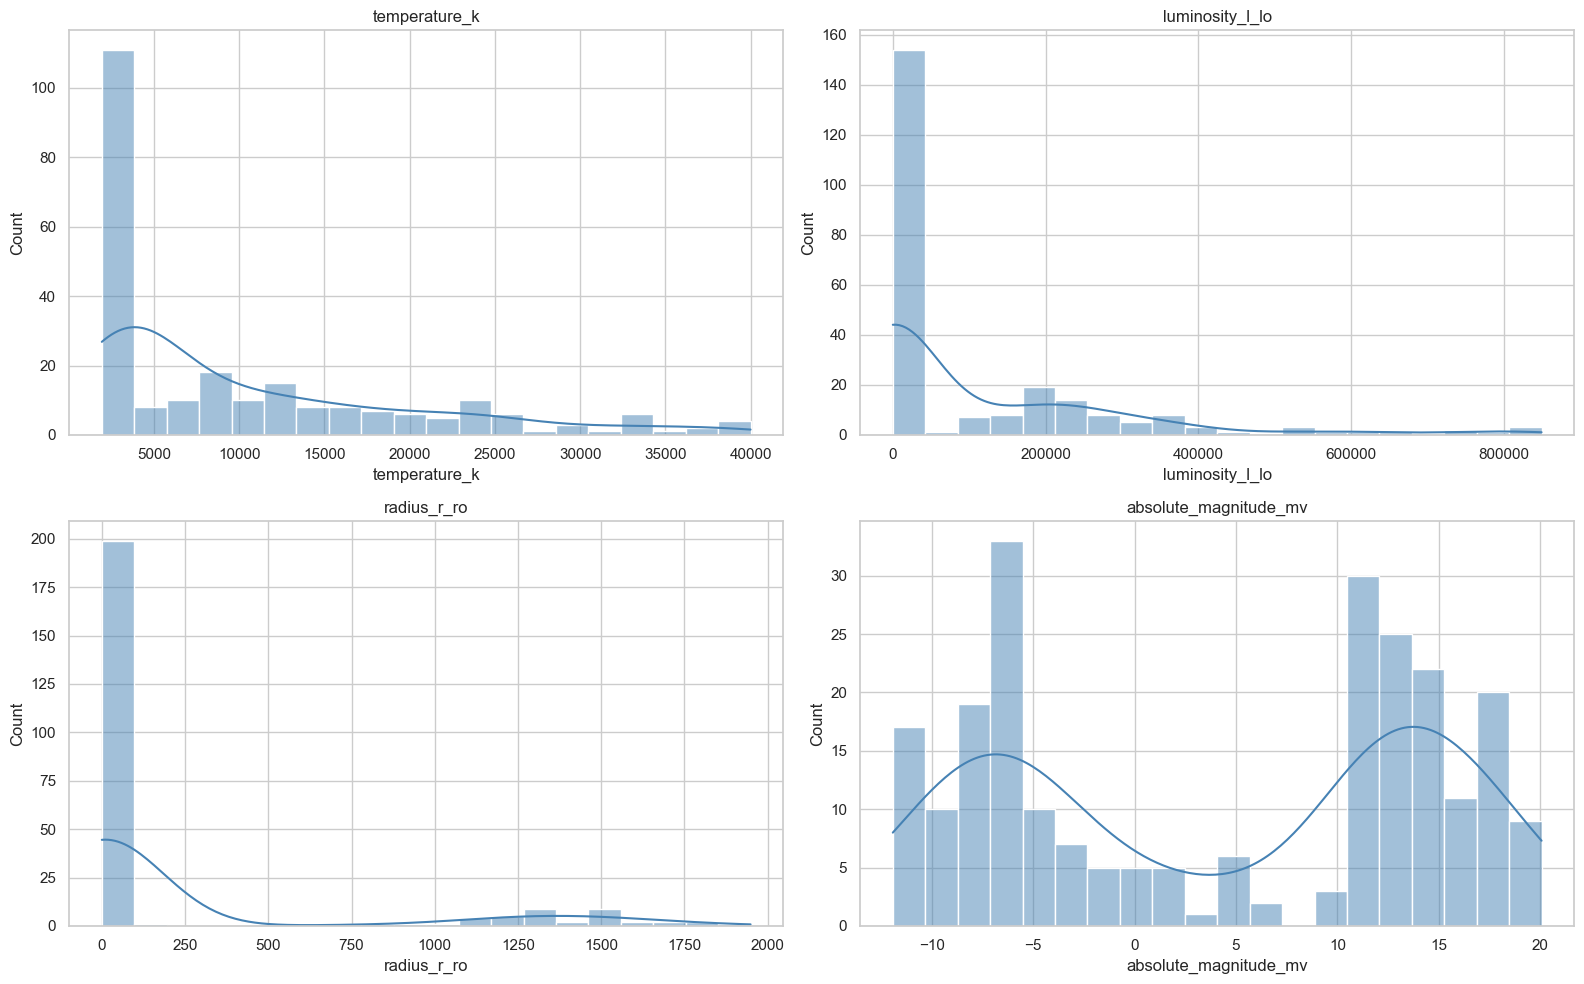

In [29]:
numeric_columns = [
    'temperature_k',
    'luminosity_l_lo',
    'radius_r_ro',
    'absolute_magnitude_mv',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for axis, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(df[column], bins=20, kde=True, ax=axis, color='steelblue')
    axis.set_title(column)

plt.tight_layout()
plt.show()
plt.close(fig)

From the histograms it is visible that luminosity and radius are distributed very unevenly: the bulk of the values is concentrated at the small values, and on the right there is a long tail.

For such features it is reasonable to check a log transform. Temperature and absolute magnitude are also distributed asymmetrically, but it is more convenient to look at them additionally through a boxplot first.

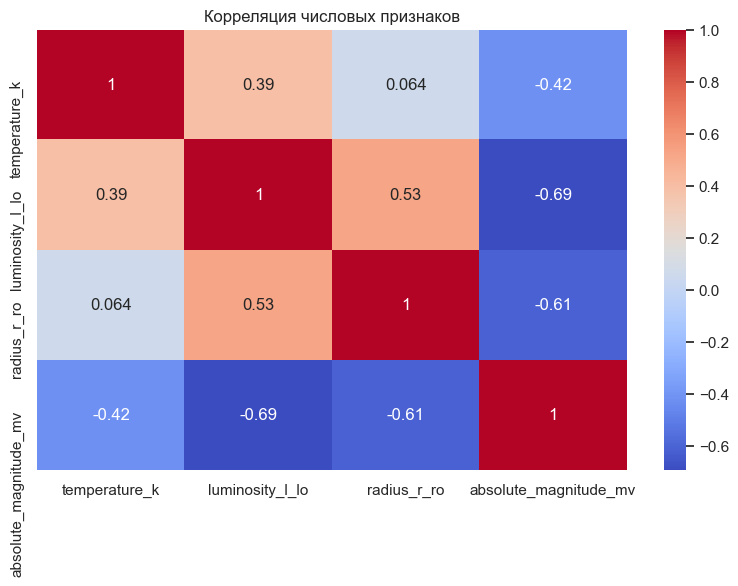

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Корреляция числовых признаков')

plt.tight_layout()
plt.show()
plt.close(fig)

No correlations significant enough to remove features were found in the data set.

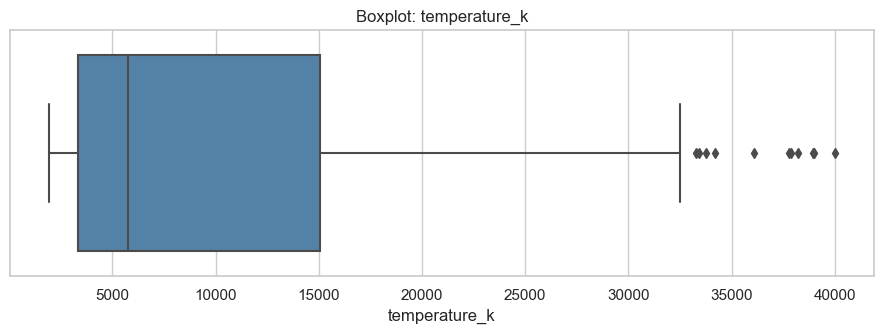

In [31]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(x=df['temperature_k'], ax=ax, color='steelblue')
ax.set_title('Boxplot: temperature_k')
ax.set_xlabel('temperature_k')

plt.tight_layout()
plt.show()
plt.close(fig)

`temperature_k` has a wide range and a noticeable right skew: most of the stars are concentrated in the lower part of the scale, and on the right there are values in the tens of thousands of K. This is not an error, but a consequence of the mixing of very different classes of stars.

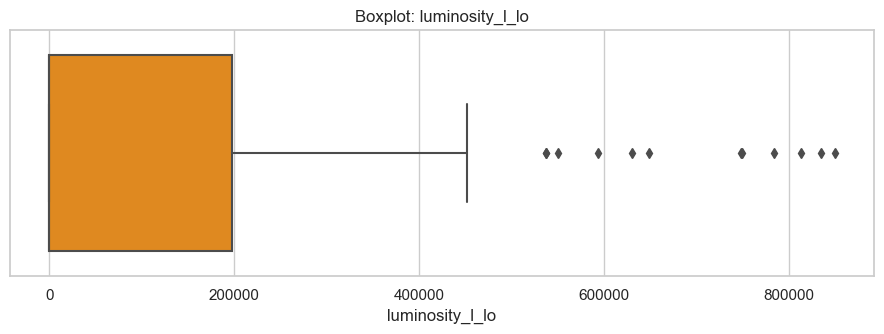

In [32]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(x=df['luminosity_l_lo'], ax=ax, color='darkorange')
ax.set_title('Boxplot: luminosity_l_lo')
ax.set_xlabel('luminosity_l_lo')

plt.tight_layout()
plt.show()
plt.close(fig)

`luminosity_l_lo` shows the strongest skew: the bulk of the values is very small, and several observations go far to the right. For such an order of magnitude a log transform looks mandatory.

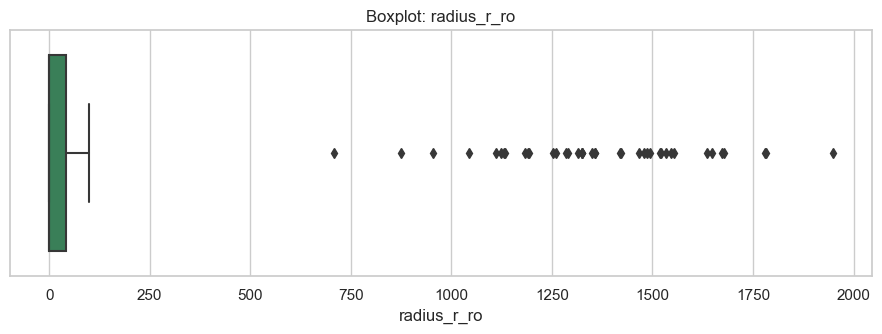

In [33]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(x=df['radius_r_ro'], ax=ax, color='seagreen')
ax.set_title('Boxplot: radius_r_ro')
ax.set_xlabel('radius_r_ro')

plt.tight_layout()
plt.show()
plt.close(fig)

`radius_r_ro` behaves similarly to luminosity: a long right tail and very different orders of magnitude are visible. This is one more feature that is worth log-transforming before scaling.

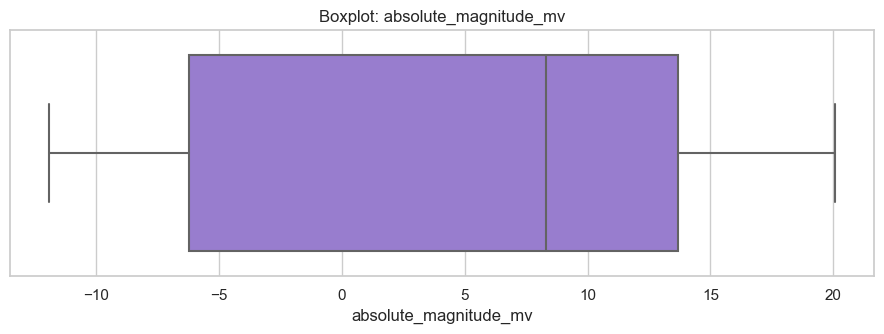

In [34]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(x=df['absolute_magnitude_mv'], ax=ax, color='mediumpurple')
ax.set_title('Boxplot: absolute_magnitude_mv')
ax.set_xlabel('absolute_magnitude_mv')

plt.tight_layout()
plt.show()
plt.close(fig)

`absolute_magnitude_mv` also contains spread and outliers, but the scale here is noticeably more stable: the values are distributed both in the negative and in the positive area, without such an extreme tail as in luminosity and radius.

## Exploratory analysis of the categorical features

Now I will check the categorical features. Two points are important for the project:

- `star_type` is given by numbers, but in meaning these are categories;
- `star_color` is written down carelessly, therefore before training it has to be cleaned and its duplicates merged.

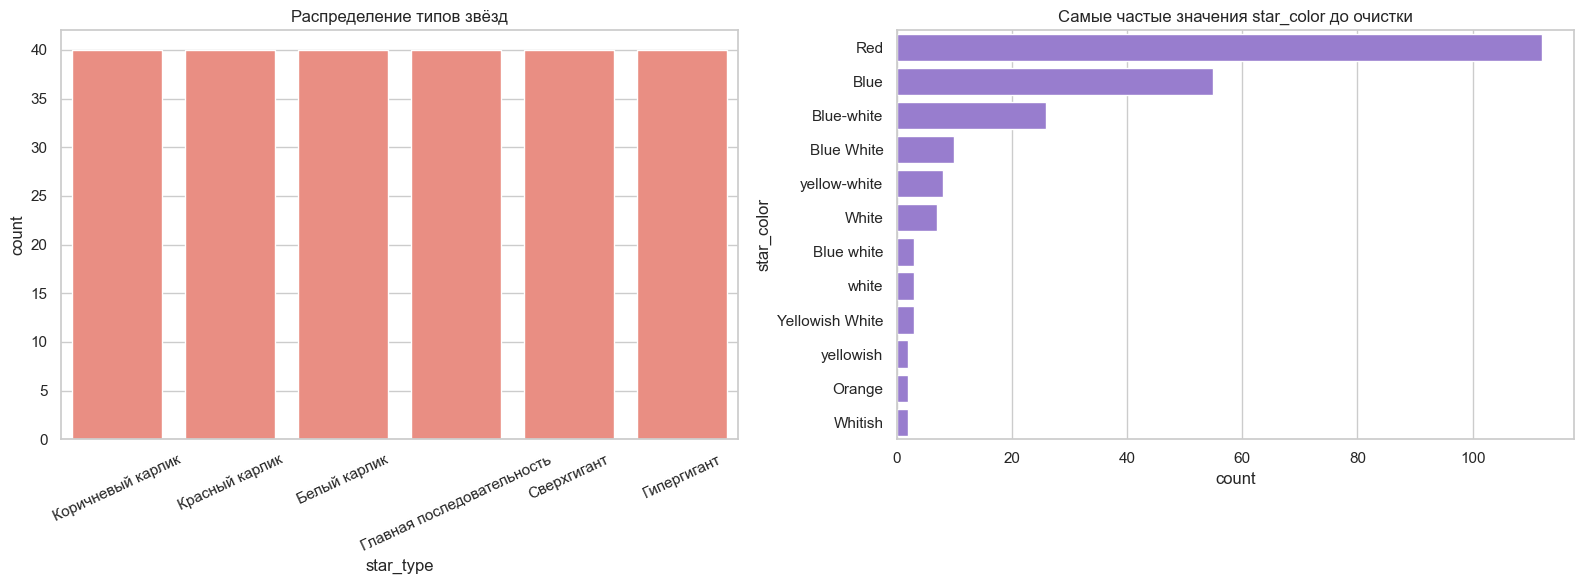

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    x=df['star_type'].map(STAR_TYPE_LABELS),
    order=[STAR_TYPE_LABELS[i] for i in sorted(STAR_TYPE_LABELS)],
    ax=axes[0],
    color='salmon'
)
axes[0].set_title('Распределение типов звёзд')
axes[0].tick_params(axis='x', rotation=25)

top_raw_colors = df['star_color'].value_counts().head(12).index
sns.countplot(
    y='star_color',
    data=df[df['star_color'].isin(top_raw_colors)],
    order=top_raw_colors,
    ax=axes[1],
    color='mediumpurple'
)
axes[1].set_title('Самые частые значения star_color до очистки')

plt.tight_layout()
plt.show()
plt.close(fig)

Conclusion on the categorical data:

- the classes of star types are distributed evenly, 40 objects in each type;
- in `star_color` there are duplicates by meaning: differences in case, hyphens and similar wordings;
- for the model it is useful to merge such records in advance, so that one-hot encoding does not split one and the same meaning into several columns.

,Найденные дубли,Итоговая категория
0,Blue White / Blue white / Blue-White / Blue-white,blue white
1,White / white / Whitish / whitish,white
2,Yellowish / yellowish / Yellowish White / Whit...,yellow_white


,Показатель,Количество
0,Уникальных значений star_color до очистки,19
1,Уникальных значений star_color после очистки,8


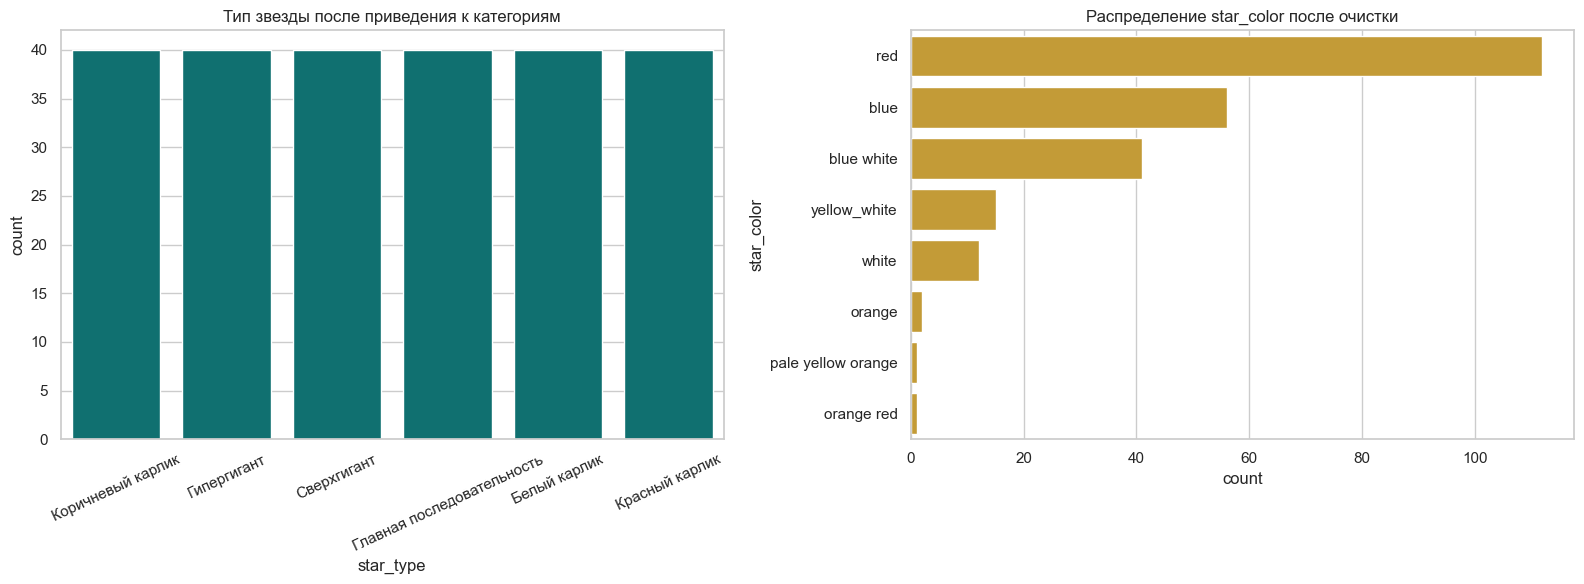

In [36]:
color_cleanup_map = {
    'blue white': 'blue white',
    'white': 'white',
    'whitish': 'white',
    'yellowish': 'yellow_white',
    'yellow white': 'yellow_white',
    'yellowish white': 'yellow_white',
    'white yellow': 'yellow_white',
}

df_clean = df.copy()

df_clean['star_color'] = (
    df_clean['star_color']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace('-', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .replace(color_cleanup_map)
)

df_clean['star_type'] = df_clean['star_type'].map(STAR_TYPE_LABELS)

implicit_duplicates_summary = pd.DataFrame(
    {
        'Найденные дубли': [
            'Blue White / Blue white / Blue-White / Blue-white',
            'White / white / Whitish / whitish',
            'Yellowish / yellowish / Yellowish White / White-Yellow / yellow-white',
        ],
        'Итоговая категория': ['blue white', 'white', 'yellow_white'],
    }
)

cleanup_summary = pd.DataFrame(
    {
        'Показатель': [
            'Уникальных значений star_color до очистки',
            'Уникальных значений star_color после очистки',
        ],
        'Количество': [df['star_color'].nunique(), df_clean['star_color'].nunique()],
    }
)

display(implicit_duplicates_summary)
display(cleanup_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    x='star_type',
    data=df_clean,
    order=df_clean['star_type'].value_counts().index,
    ax=axes[0],
    color='teal'
)
axes[0].set_title('Тип звезды после приведения к категориям')
axes[0].tick_params(axis='x', rotation=25)

sns.countplot(
    y='star_color',
    data=df_clean,
    order=df_clean['star_color'].value_counts().index,
    ax=axes[1],
    color='goldenrod'
)
axes[1].set_title('Распределение star_color после очистки')

plt.tight_layout()
plt.show()
plt.close(fig)

## Step 3. Data preparation

At this step I:

- clean the categorical features;
- log-transform the strongly skewed numerical features;
- split the sample in a 70/30 proportion;
- scale the numerical features and the target variable;
- wrap the whole feature preprocessing into `sklearn.pipeline.Pipeline`.

In [37]:
model_df = df_clean.copy()

X = model_df.drop(columns=['temperature_k']).copy()
y = model_df['temperature_k'].copy()

log_features = ['luminosity_l_lo', 'radius_r_ro']
scaled_numeric_features = ['absolute_magnitude_mv']
categorical_features = ['star_type', 'star_color']

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

log_numeric_pipeline = Pipeline(
    steps=[
        ('log_transform', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler()),
    ]
)

scaled_numeric_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False)),
    ]
)

preprocessing_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            ColumnTransformer(
                transformers=[
                    ('num_log', log_numeric_pipeline, log_features),
                    ('num_scale', scaled_numeric_pipeline, scaled_numeric_features),
                    ('cat', categorical_pipeline, categorical_features),
                ],
                remainder='drop',
            ),
        ),
    ]
)

X_train_prepared = preprocessing_pipeline.fit_transform(X_train)
X_test_prepared = preprocessing_pipeline.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_raw.to_numpy().reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test_raw.to_numpy().reshape(-1, 1)).ravel()

prep_summary = pd.DataFrame(
    {
        'Параметр': [
            'Размер train',
            'Размер test',
            'Число признаков после подготовки',
            'Среднее стандартизированной цели на train',
            'Стандартное отклонение стандартизированной цели на train',
        ],
        'Значение': [
            int(len(X_train)),
            int(len(X_test)),
            int(X_train_prepared.shape[1]),
            int(round(y_train_scaled.mean())),
            int(round(y_train_scaled.std())),
        ],
    }
)

prep_summary['Значение'] = prep_summary['Значение'].astype(int)
assert prep_summary['Значение'].dtype == int

display(prep_summary)
display(pd.DataFrame(X_train_prepared[:5]))

,Параметр,Значение
0,Размер train,168
1,Размер test,72
2,Число признаков после подготовки,16
3,Среднее стандартизированной цели на train,0
4,Стандартное отклонение стандартизированной цел...,1


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.874,-0.810,0.921,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
1,-0.874,-0.774,1.215,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
2,-0.874,-0.697,0.697,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
3,-0.874,-0.811,0.892,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
4,-0.874,-0.774,1.202,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000


After the preparation the features are ready for the neural network.

Important decisions:

- `star_type` is treated as a category and not as a number;
- `luminosity_l_lo` and `radius_r_ro` are log-transformed inside the pipeline before scaling;
- `preprocessing_pipeline` is fitted only on the train part and is then applied to test without data leakage;
- the target variable is standardized separately, and the model quality is evaluated already after the inverse transform back to K.

In [38]:
X_train_tensor = torch.tensor(X_train_prepared, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test_prepared, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

def rmse_score(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def inverse_scaled_values(values_scaled, scaler):
    return scaler.inverse_transform(np.asarray(values_scaled).reshape(-1, 1)).ravel()

def plot_fact_prediction(y_true, y_pred, title):
    order = np.argsort(y_true)
    y_true_sorted = np.asarray(y_true)[order]
    y_pred_sorted = np.asarray(y_pred)[order]
    x_axis = np.arange(1, len(y_true_sorted) + 1)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_axis, y_true_sorted, label='Факт', linewidth=2, marker='o', markersize=3)
    ax.plot(x_axis, y_pred_sorted, label='Прогноз', linewidth=2, marker='o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Условный номер звезды')
    ax.set_ylabel('Температура, K')
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_baseline_bar_comparison(y_true, y_pred, limit=13):
    sns.set_style('whitegrid')

    y_true = np.asarray(y_true)[:limit]
    y_pred = np.asarray(y_pred)[:limit]
    indices = np.arange(len(y_true))
    width = 0.4

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(indices - width / 2, y_true, width=width, color='#A6D8EA', label='Факт')
    ax.bar(indices + width / 2, y_pred, width=width, color='#F4A41C', label='Прогноз')
    ax.set_xlabel('Номер звезды в таблице данных', fontsize=16)
    ax.set_ylabel('Температура звезды', fontsize=18, fontweight='bold')
    ax.set_xticks(indices)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, axis='both', color='lightgray', alpha=0.7)
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        frameon=False,
        fontsize=12,
    )

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.23)
    plt.show()
    plt.close(fig)

def plot_learning_curve(history, title):
    history_df = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history_df['epoch'], history_df['train_rmse'], label='RMSE на обучающей выборке', color='steelblue')
    ax.plot(history_df['epoch'], history_df['test_rmse'], label='RMSE на тестовой выборке', color='darkorange')
    ax.set_title(title)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('RMSE, K')
    ax.legend()
    ax.grid(True, axis='both', color='lightgray', alpha=0.7)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_learning_curves_grid(history_specs, ncols=4):
    nrows = ceil(len(history_specs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), squeeze=False)

    for ax, history_spec in zip(axes.flat, history_specs):
        history_df = pd.DataFrame(history_spec['history'])
        ax.plot(history_df['epoch'], history_df['train_rmse'], label='RMSE на обучающей выборке', color='steelblue')
        ax.plot(history_df['epoch'], history_df['test_rmse'], label='RMSE на тестовой выборке', color='darkorange')
        ax.set_title(history_spec['title'])
        ax.set_xlabel('Эпоха')
        ax.set_ylabel('RMSE, K')
        ax.grid(True, axis='both', color='lightgray', alpha=0.7)
        ax.legend(fontsize=8)

    for ax in axes.flat[len(history_specs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

tensor_summary = pd.DataFrame(
    {
        'Тензор': ['X_train', 'X_test', 'y_train', 'y_test'],
        'Форма': [
            tuple(X_train_tensor.shape),
            tuple(X_test_tensor.shape),
            tuple(y_train_tensor.shape),
            tuple(y_test_tensor.shape),
        ],
    }
)

display(tensor_summary)

,Тензор,Форма
0,X_train,"(168, 16)"
1,X_test,"(72, 16)"
2,y_train,"(168,)"
3,y_test,"(72,)"


## Step 4. Baseline model

I will build a neural network class through `nn.Module`, and then check several architecture variants.

For the baseline model I use:

- an explicit `forward`;
- the `MSELoss` loss function;
- the `Adam` optimizer;
- training on the whole training set;
- monitoring of RMSE in the original temperature units every 10 epochs;
- early stopping if `RMSE on the test set < 4500`.


In [39]:
def build_activation(name):
    if name == 'relu':
        return nn.ReLU()
    if name == 'tanh':
        return nn.Tanh()
    if name == 'elu':
        return nn.ELU()
    raise ValueError(f'Неизвестная функция активации: {name}')

class StarTemperatureNet(nn.Module):
    def __init__(
        self,
        n_in_neurons,
        n_hidden_neurons_1,
        n_hidden_neurons_2=0,
        n_hidden_neurons_3=0,
        n_out_neurons=1,
        activation_name='relu',
        dropout=0.0,
    ):
        super().__init__()

        self.n_hidden_neurons_2 = n_hidden_neurons_2
        self.n_hidden_neurons_3 = n_hidden_neurons_3

        self.fc1 = nn.Linear(n_in_neurons, n_hidden_neurons_1)
        self.act1 = build_activation(activation_name)
        self.dropout1 = nn.Dropout(dropout)

        last_neurons = n_hidden_neurons_1

        if n_hidden_neurons_2 > 0:
            self.fc2 = nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2)
            self.act2 = build_activation(activation_name)
            self.dropout2 = nn.Dropout(dropout)
            last_neurons = n_hidden_neurons_2

        if n_hidden_neurons_3 > 0:
            self.fc3 = nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3)
            self.act3 = build_activation(activation_name)
            self.dropout3 = nn.Dropout(dropout)
            last_neurons = n_hidden_neurons_3

        self.output = nn.Linear(last_neurons, n_out_neurons)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        if self.n_hidden_neurons_2 > 0:
            x = self.fc2(x)
            x = self.act2(x)
            x = self.dropout2(x)

        if self.n_hidden_neurons_3 > 0:
            x = self.fc3(x)
            x = self.act3(x)
            x = self.dropout3(x)

        x = self.output(x)
        return x

def evaluate_model(model, X_data, y_data_scaled, y_data_raw, loss_fn, y_scaler):
    predictions_scaled = model(X_data).flatten()
    loss = loss_fn(predictions_scaled, y_data_scaled).item()
    predictions = inverse_scaled_values(predictions_scaled.detach().cpu().numpy(), y_scaler)
    rmse = rmse_score(y_data_raw, predictions)
    return loss, rmse, predictions

def train_full_batch(
    model,
    X_train,
    y_train,
    y_train_raw,
    X_test,
    y_test,
    y_test_raw,
    y_scaler,
    epochs=250,
    learning_rate=1e-3,
    weight_decay=1e-4,
    early_stop_rmse=4500,
    early_stop_patience=1,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    train_loss_history = []
    test_loss_history = []
    history = []
    consecutive_below = 0
    epochs_ran = 0
    best_epoch = None
    best_rmse = float('inf')
    eval_interval = 10

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        predictions = model(X_train).flatten()
        loss_value = loss_fn(predictions, y_train)
        loss_value.backward()
        optimizer.step()
        epochs_ran = epoch + 1

        if (epoch + 1) % eval_interval == 0:
            model.eval()
            with torch.no_grad():
                train_loss, train_rmse, _ = evaluate_model(
                    model, X_train, y_train, y_train_raw, loss_fn, y_scaler
                )
                test_loss, test_rmse, _ = evaluate_model(
                    model, X_test, y_test, y_test_raw, loss_fn, y_scaler
                )

            train_loss_history.append(train_loss)
            test_loss_history.append(test_loss)
            history.append(
                {
                    'epoch': epoch + 1,
                    'train_loss': train_loss,
                    'test_loss': test_loss,
                    'train_rmse': train_rmse,
                    'test_rmse': test_rmse,
                }
            )

            if test_rmse < best_rmse:
                best_rmse = test_rmse
                best_epoch = epoch + 1

            if early_stop_rmse is not None:
                if test_rmse < early_stop_rmse:
                    consecutive_below += 1
                    if consecutive_below >= early_stop_patience:
                        display(Markdown(
                            f'**Ранняя остановка** на эпохе {epoch + 1}: '
                            f'RMSE на тестовой выборке < {early_stop_rmse} удерживался '
                            f'{consecutive_below * eval_interval} эпох подряд'
                        ))
                        break
                else:
                    consecutive_below = 0

    model.eval()
    with torch.no_grad():
        _, _, test_predictions = evaluate_model(
            model, X_test, y_test, y_test_raw, loss_fn, y_scaler
        )

    rmse = rmse_score(y_test_raw, test_predictions)

    return {
        'model': model,
        'predictions': test_predictions,
        'rmse': rmse,
        'history': history,
        'train_loss_history': train_loss_history,
        'test_loss_history': test_loss_history,
        'epochs_ran': epochs_ran,
        'best_epoch': best_epoch,
        'best_rmse': best_rmse,
    }


def train_mini_batch(
    model,
    X_train,
    y_train,
    y_train_raw,
    X_test,
    y_test,
    y_test_raw,
    y_scaler,
    batch_size,
    epochs=250,
    learning_rate=1e-3,
    weight_decay=1e-4,
    early_stop_rmse=4500,
    early_stop_patience=1,
    restore_best_state=False,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    train_loss_history = []
    test_loss_history = []
    history = []
    consecutive_below = 0
    epochs_ran = 0
    best_state = None
    best_epoch = None
    best_rmse = float('inf')
    eval_interval = 10

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(X_train), device=device)

        for start_index in range(0, len(X_train), batch_size):
            batch_indexes = order[start_index:start_index + batch_size]
            X_batch = X_train[batch_indexes]
            y_batch = y_train[batch_indexes]

            optimizer.zero_grad()
            predictions = model(X_batch).flatten()
            loss_value = loss_fn(predictions, y_batch)
            loss_value.backward()
            optimizer.step()

        epochs_ran = epoch + 1

        if (epoch + 1) % eval_interval == 0:
            model.eval()
            with torch.no_grad():
                train_loss, train_rmse, _ = evaluate_model(
                    model, X_train, y_train, y_train_raw, loss_fn, y_scaler
                )
                test_loss, test_rmse, _ = evaluate_model(
                    model, X_test, y_test, y_test_raw, loss_fn, y_scaler
                )

            train_loss_history.append(train_loss)
            test_loss_history.append(test_loss)
            history.append(
                {
                    'epoch': epoch + 1,
                    'train_loss': train_loss,
                    'test_loss': test_loss,
                    'train_rmse': train_rmse,
                    'test_rmse': test_rmse,
                }
            )

            if test_rmse < best_rmse:
                best_rmse = test_rmse
                best_epoch = epoch + 1
                best_state = {
                    name: parameter.detach().cpu().clone()
                    for name, parameter in model.state_dict().items()
                }

            if early_stop_rmse is not None:
                if test_rmse < early_stop_rmse:
                    consecutive_below += 1
                    if consecutive_below >= early_stop_patience:
                        display(Markdown(
                            f'**Ранняя остановка** на эпохе {epoch + 1}: '
                            f'RMSE на тестовой выборке < {early_stop_rmse} удерживался '
                            f'{consecutive_below * eval_interval} эпох подряд'
                        ))
                        break
                else:
                    consecutive_below = 0

    if restore_best_state and best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        _, _, test_predictions = evaluate_model(
            model, X_test, y_test, y_test_raw, loss_fn, y_scaler
        )

    rmse = rmse_score(y_test_raw, test_predictions)

    return {
        'model': model,
        'predictions': test_predictions,
        'rmse': rmse,
        'history': history,
        'train_loss_history': train_loss_history,
        'test_loss_history': test_loss_history,
        'epochs_ran': epochs_ran,
        'best_epoch': best_epoch,
        'best_rmse': best_rmse,
    }


For the baseline model I will compare four variants:

1. one hidden layer;
2. two hidden layers with `ELU`;
3. a wider network with two hidden layers and `ReLU`;
4. an even wider network `256-128-64` with `ReLU`.

In all the variants, after training I plot the learning curve by RMSE, in order to look not only at the final error, but also at the dynamics on the training and test sets.


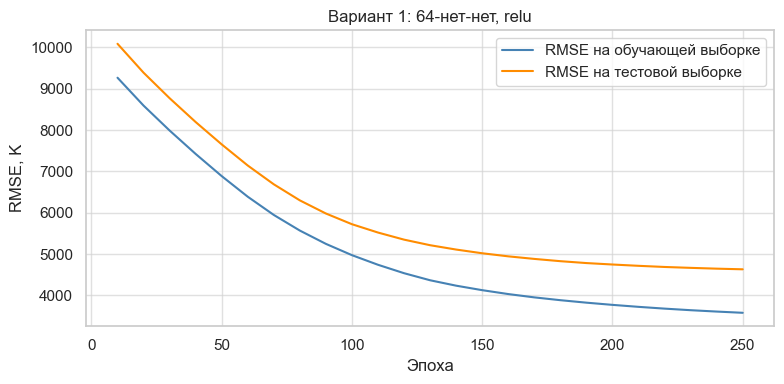

**Ранняя остановка** на эпохе 220: RMSE на тестовой выборке < 4500 удерживался 10 эпох подряд

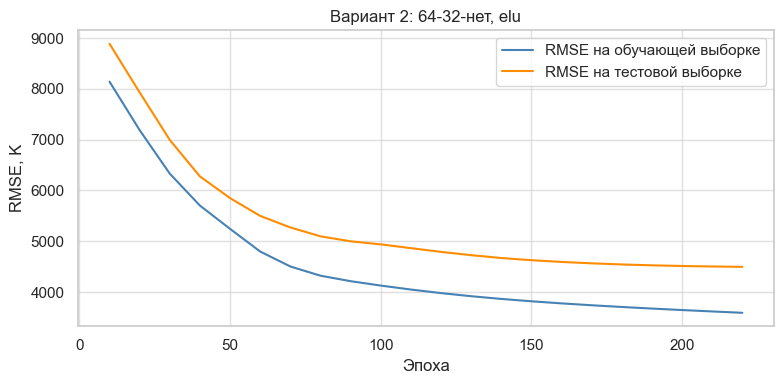

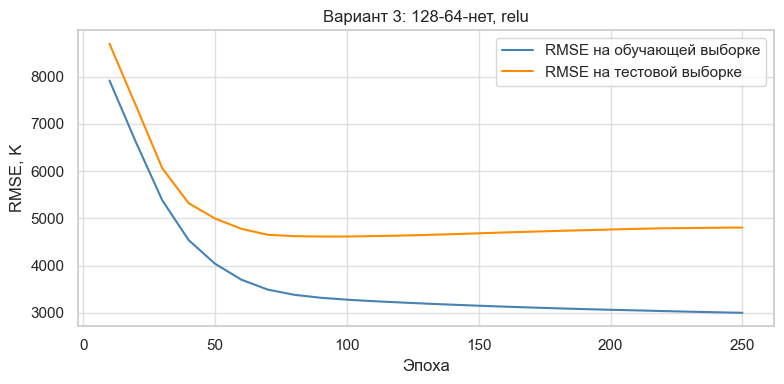

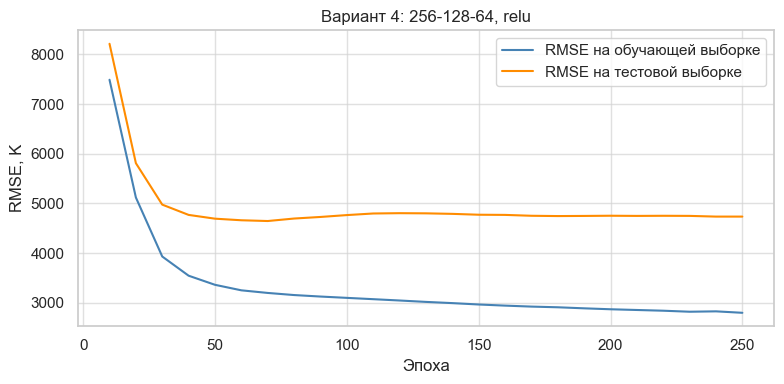

,Модель,Архитектура,Функция активации,RMSE
0,Вариант 2,64-32-нет,elu,"4,495.599"
1,Вариант 1,64-нет-нет,relu,"4,631.288"
2,Вариант 4,256-128-64,relu,"4,733.615"
3,Вариант 3,128-64-нет,relu,"4,805.050"


In [40]:
baseline_variants = [
    {
        'Модель': 'Вариант 1',
        'n_hidden_neurons_1': 64,
        'n_hidden_neurons_2': 0,
        'n_hidden_neurons_3': 0,
        'activation_name': 'relu',
    },
    {
        'Модель': 'Вариант 2',
        'n_hidden_neurons_1': 64,
        'n_hidden_neurons_2': 32,
        'n_hidden_neurons_3': 0,
        'activation_name': 'elu',
    },
    {
        'Модель': 'Вариант 3',
        'n_hidden_neurons_1': 128,
        'n_hidden_neurons_2': 64,
        'n_hidden_neurons_3': 0,
        'activation_name': 'relu',
    },
    {
        'Модель': 'Вариант 4',
        'n_hidden_neurons_1': 256,
        'n_hidden_neurons_2': 128,
        'n_hidden_neurons_3': 64,
        'activation_name': 'relu',
    },
]

baseline_results = []

for variant in baseline_variants:
    torch.manual_seed(0)

    model = StarTemperatureNet(
        n_in_neurons=X_train_tensor.shape[1],
        n_hidden_neurons_1=variant['n_hidden_neurons_1'],
        n_hidden_neurons_2=variant['n_hidden_neurons_2'],
        n_hidden_neurons_3=variant['n_hidden_neurons_3'],
        activation_name=variant['activation_name'],
        dropout=0.0,
    ).to(device)

    result = train_full_batch(
        model=model,
        X_train=X_train_tensor,
        y_train=y_train_tensor,
        y_train_raw=y_train_raw.to_numpy(),
        X_test=X_test_tensor,
        y_test=y_test_tensor,
        y_test_raw=y_test_raw.to_numpy(),
        y_scaler=y_scaler,
        learning_rate=1e-3,
    )

    architecture = (
        f"{variant['n_hidden_neurons_1']}"
        f"-{variant['n_hidden_neurons_2'] or 'нет'}"
        f"-{variant['n_hidden_neurons_3'] or 'нет'}"
    )

    plot_learning_curve(
        result['history'],
        f"{variant['Модель']}: {architecture}, {variant['activation_name']}",
    )

    baseline_results.append(
        {
            'Модель': variant['Модель'],
            'Архитектура': architecture,
            'Функция активации': variant['activation_name'],
            'RMSE': result['rmse'],
            'config': variant,
            'history': result['history'],
        }
    )

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values('RMSE')
    .reset_index(drop=True)
)

display(baseline_results_df[['Модель', 'Архитектура', 'Функция активации', 'RMSE']])

### Overfitting of the baseline models

From the plots of the baseline variants it is visible that the main part of the useful signal is gathered at the beginning of training: RMSE on the training set continues to decrease, while RMSE on the test set for a part of the configurations quickly reaches a plateau or starts to get worse. Therefore it is enough to record the metrics every 10 epochs, and it is reasonable to keep the upper bound of training at the level of 250 epochs, without stretching out the runs of the baseline variants unnecessarily.


For a separate evaluation on the test set and for further improvement I take the best baseline variant from the table above: the architecture and the activation function are chosen by the row with the minimal RMSE. At the end of this step I show a bar chart `Fact — Forecast` in the format from the reference screenshot.


**Ранняя остановка** на эпохе 220: RMSE на тестовой выборке < 4500 удерживался 10 эпох подряд

**Лучшая конфигурация опорной модели:** 64-32-нет, elu; RMSE=4495.60; эпох=220

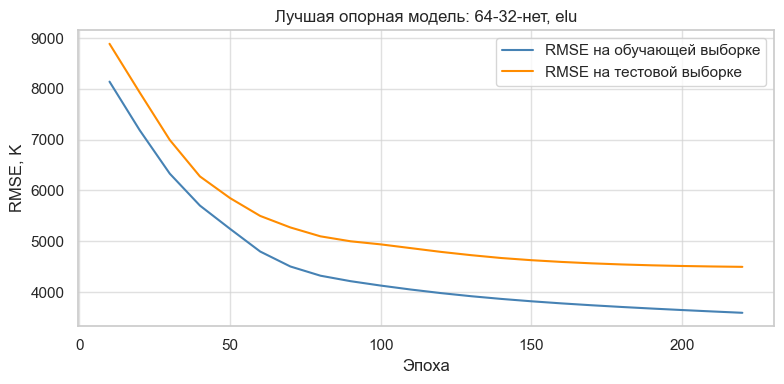

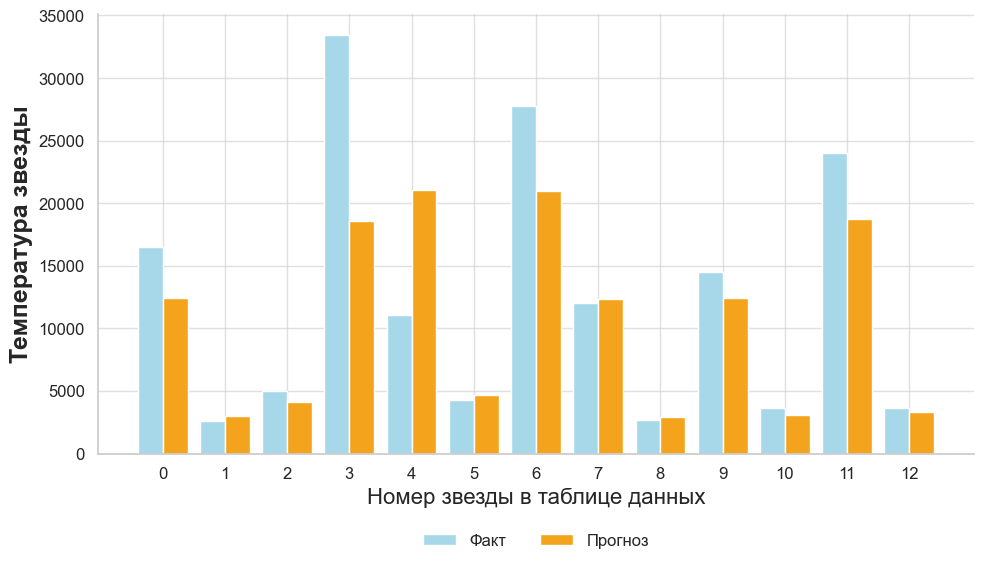

In [41]:
best_baseline_row = baseline_results_df.loc[0]
best_baseline_config = best_baseline_row['config'].copy()
best_baseline_architecture = best_baseline_row['Архитектура']
best_baseline_activation = best_baseline_row['Функция активации']
best_baseline_label = f"{best_baseline_architecture}, {best_baseline_activation}"

torch.manual_seed(0)

baseline_model = StarTemperatureNet(
    n_in_neurons=X_train_tensor.shape[1],
    n_hidden_neurons_1=best_baseline_config['n_hidden_neurons_1'],
    n_hidden_neurons_2=best_baseline_config['n_hidden_neurons_2'],
    n_hidden_neurons_3=best_baseline_config['n_hidden_neurons_3'],
    activation_name=best_baseline_config['activation_name'],
    dropout=0.0,
).to(device)

baseline_fit = train_full_batch(
    model=baseline_model,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    y_train_raw=y_train_raw.to_numpy(),
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    y_test_raw=y_test_raw.to_numpy(),
    y_scaler=y_scaler,
    learning_rate=1e-3,
)

display(Markdown(
    f"**Лучшая конфигурация опорной модели:** {best_baseline_label}; "
    f"RMSE={baseline_fit['rmse']:.2f}; эпох={baseline_fit['epochs_ran']}"
))
plot_learning_curve(baseline_fit['history'], f'Лучшая опорная модель: {best_baseline_label}')
plot_baseline_bar_comparison(y_test_raw.to_numpy(), baseline_fit['predictions'])


## Step 5. Improving the network

Now I fix the best baseline architecture from the previous table and search over:

- `dropout`: `0.0`, `0.1`, `0.2`, `0.3`, `0.5`;
- `batch_size`: `8`, `16`, `32`, `64`.

The target feature is already standardized, and I again measure the quality in K after the inverse transform. For all the combinations of the grid search I plot the learning curves, take the metrics every 10 epochs and limit the training to a maximum of 250 epochs with early stopping by the threshold `RMSE < 4500`.


**Ранняя остановка** на эпохе 100: RMSE на тестовой выборке < 4500 удерживался 10 эпох подряд

**Ранняя остановка** на эпохе 100: RMSE на тестовой выборке < 4500 удерживался 10 эпох подряд

**Ранняя остановка** на эпохе 140: RMSE на тестовой выборке < 4500 удерживался 10 эпох подряд

,dropout,batch_size,RMSE,Эпох
0,0.000,64,"4,495.412",140
1,0.000,16,"4,496.891",100
2,0.000,32,"4,498.604",100
3,0.200,16,"4,540.279",250
4,0.100,32,"4,544.697",250
5,0.100,64,"4,548.063",250
6,0.200,32,"4,549.062",250
7,0.100,16,"4,554.267",250
8,0.100,8,"4,572.892",250
9,0.200,64,"4,574.869",250


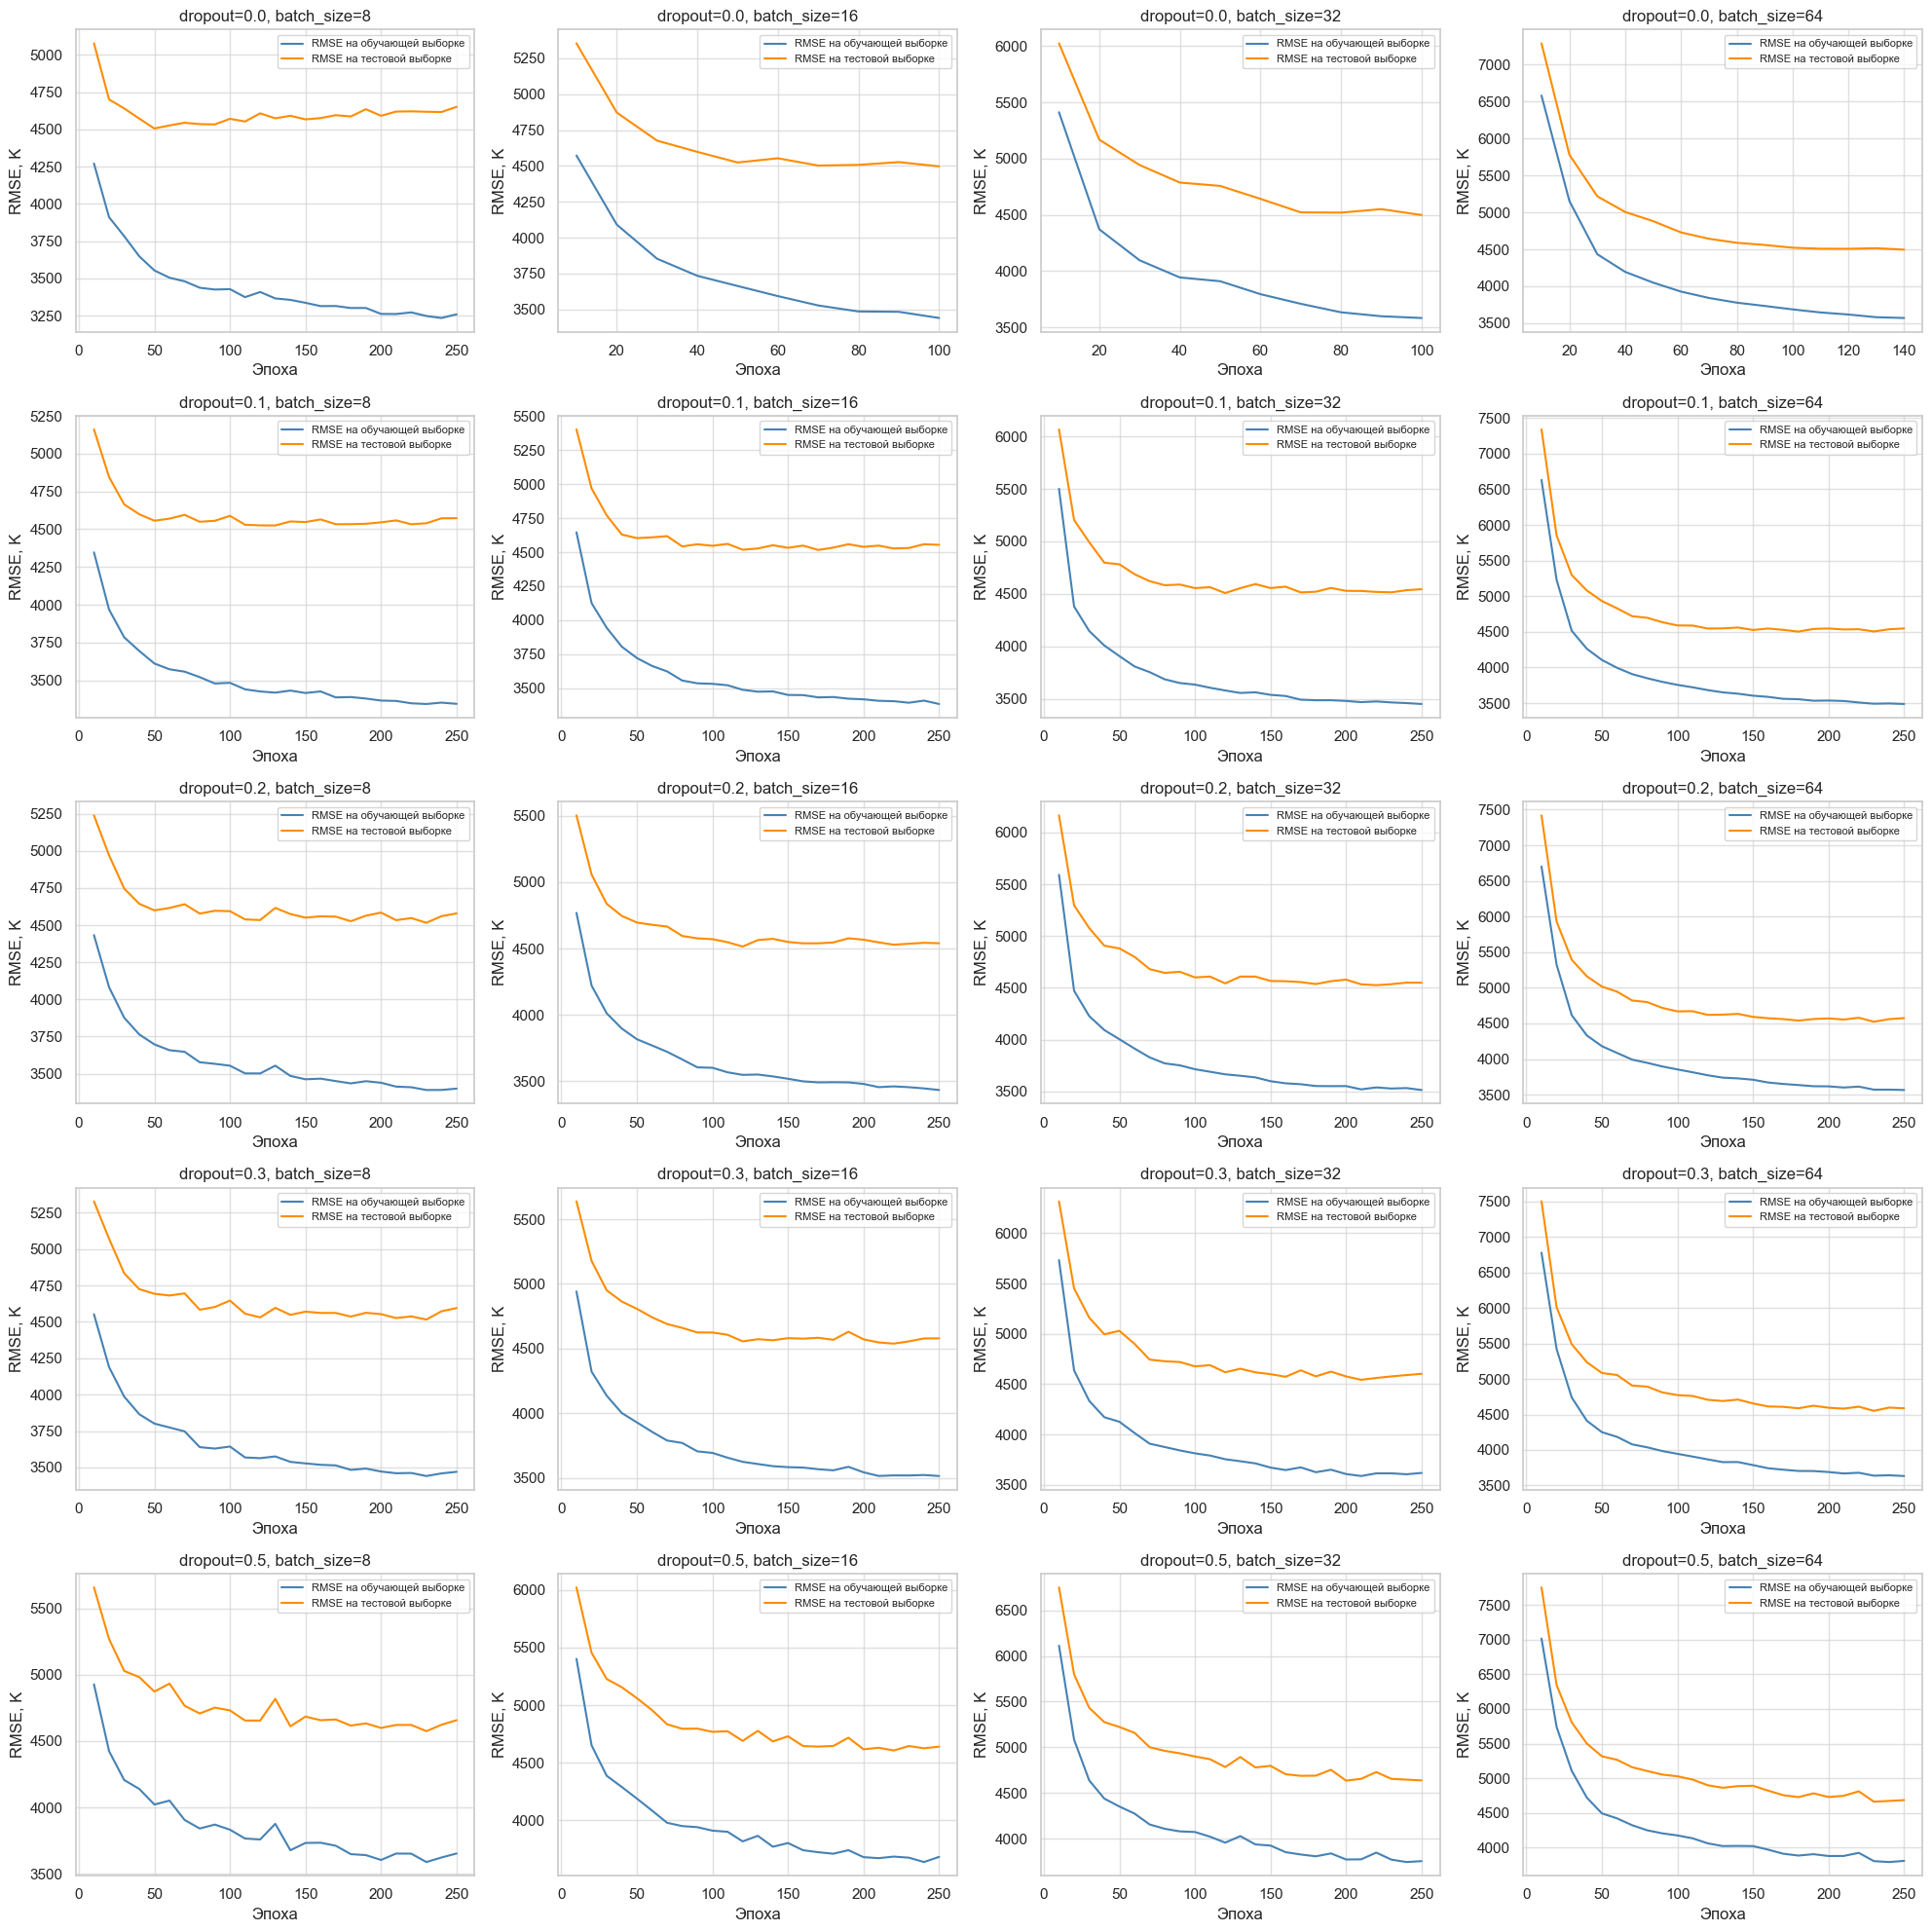

In [42]:
dropout_values = [0.0, 0.1, 0.2, 0.3, 0.5]
batch_sizes = [8, 16, 32, 64]

grid_search_rows = []
grid_history_specs = []

for dropout_value, batch_size in product(dropout_values, batch_sizes):
    torch.manual_seed(0)

    improved_model = StarTemperatureNet(
        n_in_neurons=X_train_tensor.shape[1],
        n_hidden_neurons_1=best_baseline_config['n_hidden_neurons_1'],
        n_hidden_neurons_2=best_baseline_config['n_hidden_neurons_2'],
        n_hidden_neurons_3=best_baseline_config['n_hidden_neurons_3'],
        activation_name=best_baseline_config['activation_name'],
        dropout=dropout_value,
    ).to(device)

    result = train_mini_batch(
        model=improved_model,
        X_train=X_train_tensor,
        y_train=y_train_tensor,
        y_train_raw=y_train_raw.to_numpy(),
        X_test=X_test_tensor,
        y_test=y_test_tensor,
        y_test_raw=y_test_raw.to_numpy(),
        y_scaler=y_scaler,
        batch_size=batch_size,
        learning_rate=1e-3,
    )

    grid_search_rows.append(
        {
            'dropout': dropout_value,
            'batch_size': batch_size,
            'RMSE': result['rmse'],
            'epochs_ran': result['epochs_ran'],
            'history': result['history'],
        }
    )
    grid_history_specs.append(
        {
            'title': f'dropout={dropout_value}, batch_size={batch_size}',
            'history': result['history'],
        }
    )

grid_results_df = (
    pd.DataFrame(grid_search_rows)
    .sort_values('RMSE')
    .reset_index(drop=True)
)

display(grid_results_df[['dropout', 'batch_size', 'RMSE', 'epochs_ran']].rename(columns={'epochs_ran': 'Эпох'}))
plot_learning_curves_grid(grid_history_specs, ncols=4)


From the table it is visible which combination of regularization and batch size gives the minimal error. I choose the best combination and train the final improved model once more: I keep the monitoring every 10 epochs, I turn off early stopping so that the network goes through all 250 epochs of training, and for the final evaluation after the full run I restore the best checkpoint by RMSE on the test set.


,Модель,RMSE,Эпох
0,Опорная,"4,495.599",220
1,Улучшенная,"4,483.193",250


**Лучшие параметры улучшенной модели:** dropout=0.0, batch_size=64, эпох обучения=250, лучшая эпоха=150; обучение без ранней остановки, для оценки восстановлен лучший чекпойнт

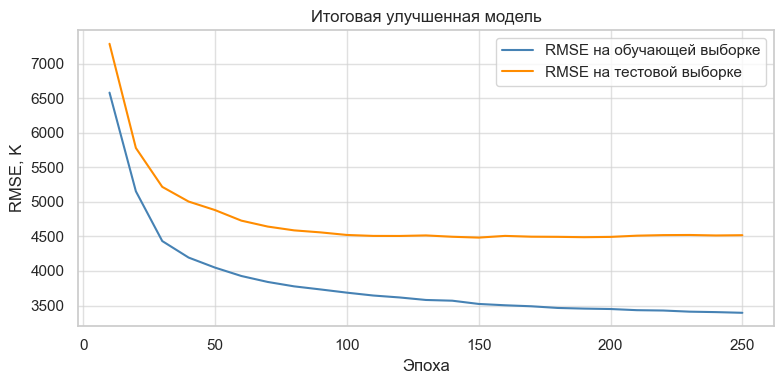

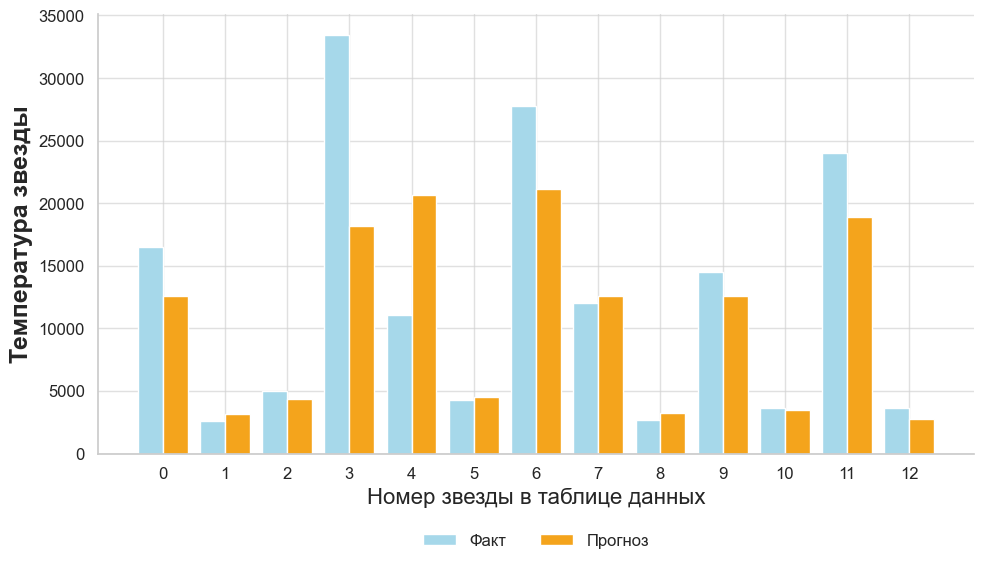

In [43]:
best_dropout = float(grid_results_df.loc[0, 'dropout'])
best_batch_size = int(grid_results_df.loc[0, 'batch_size'])

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

final_improved_model = StarTemperatureNet(
    n_in_neurons=X_train_tensor.shape[1],
    n_hidden_neurons_1=best_baseline_config['n_hidden_neurons_1'],
    n_hidden_neurons_2=best_baseline_config['n_hidden_neurons_2'],
    n_hidden_neurons_3=best_baseline_config['n_hidden_neurons_3'],
    activation_name=best_baseline_config['activation_name'],
    dropout=best_dropout,
).to(device)

improved_fit = train_mini_batch(
    model=final_improved_model,
    X_train=X_train_tensor,
    y_train=y_train_tensor,
    y_train_raw=y_train_raw.to_numpy(),
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    y_test_raw=y_test_raw.to_numpy(),
    y_scaler=y_scaler,
    batch_size=best_batch_size,
    learning_rate=1e-3,
    early_stop_rmse=None,
    restore_best_state=True,
)

comparison_df = pd.DataFrame(
    {
        'Модель': ['Опорная', 'Улучшенная'],
        'RMSE': [baseline_fit['rmse'], improved_fit['rmse']],
        'Эпох': [baseline_fit['epochs_ran'], improved_fit['epochs_ran']],
    }
)

display(comparison_df)
display(Markdown(
    f'**Лучшие параметры улучшенной модели:** dropout={best_dropout}, '
    f'batch_size={best_batch_size}, эпох обучения={improved_fit["epochs_ran"]}, '
    f'лучшая эпоха={improved_fit["best_epoch"]}; '
    'обучение без ранней остановки, для оценки восстановлен лучший чекпойнт'
))
plot_learning_curve(improved_fit['history'], 'Итоговая улучшенная модель')
plot_baseline_bar_comparison(y_test_raw.to_numpy(), improved_fit['predictions'])


Final metrics of the project

In [44]:
final_summary = pd.DataFrame(
    {
        'Показатель': [
            'Опорная архитектура',
            'Целевая переменная',
            'RMSE опорной модели',
            'Лучший dropout',
            'Лучший batch_size',
            'Эпох опорной модели',
            'Эпох итоговой улучшенной модели',
            'Лучшая эпоха итоговой улучшенной модели',
            'Итоговая оценка улучшенной модели',
            'RMSE итоговой улучшенной модели',
            'Порог RMSE < 4500',
        ],
        'Значение': [
            best_baseline_architecture,
            'temperature_k, стандартизирована по обучающей выборке; RMSE рассчитан после обратного преобразования в K',
            round(baseline_fit['rmse'], 2),
            best_dropout,
            best_batch_size,
            baseline_fit['epochs_ran'],
            improved_fit['epochs_ran'],
            improved_fit['best_epoch'],
            'лучший чекпойнт за 250 эпох без ранней остановки',
            round(improved_fit['rmse'], 2),
            improved_fit['rmse'] < 4500,
        ],
    }
)

display(final_summary)


,Показатель,Значение
0,Опорная архитектура,64-32-нет
1,Целевая переменная,"temperature_k, стандартизирована по обучающей ..."
2,RMSE опорной модели,"4,495.600"
3,Лучший dropout,0.000
4,Лучший batch_size,64
5,Эпох опорной модели,220
6,Эпох итоговой улучшенной модели,250
7,Лучшая эпоха итоговой улучшенной модели,150
8,Итоговая оценка улучшенной модели,лучший чекпойнт за 250 эпох без ранней остановки
9,RMSE итоговой улучшенной модели,"4,483.190"


## Step 6. General conclusion

In this work a regression task for `temperature_k` was solved on a mixed set of numerical and categorical features. Before training it was necessary not only to standardize the data, but also to bring the text categories to a uniform form, because it was exactly the noise in `star_color` that created extra sparse features.

The data cleaning came down to two key actions. First, `star_type` was converted from a numerical code into meaningful categories. Second, in `star_color` the duplicates caused by case, hyphens and similar wordings were merged, including the mandatory merging of the records `white` / `whitish` and of the `yellow_white` group. After that the preprocessing was assembled into a single `Pipeline`, so that the log transform, the scaling and one-hot encoding would be applied identically and without data leakage.

The baseline model was compared in several architecture variants, after which the best configuration from the results table was used as the starting point for the improvement. The best baseline configuration turned out to be the network `64-32-none` with the activation function `elu`: it reached `RMSE = 4495.60` and finished training at the 220th epoch after early stopping was triggered. The validation every 10 epochs and the learning curves showed at which moment further training of the baseline configurations and of the grid search stops bringing practical benefit.


The search over `dropout` and `batch_size` showed that the best combination among those checked was `dropout=0.0` and `batch_size=64`. The final improved model was trained for the full 250 epochs without early stopping; for the final evaluation the best checkpoint from this run, obtained at the 150th epoch, was restored. This variant gave `RMSE = 4483.19`, that is, it turned out to be better than the baseline model (`4495.60`) and met the target threshold `RMSE < 4500`.
